In [ ]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from xgboost import XGBClassifier


# ==========================================
# 1. DATA LOADING AND PREPARATION
# ==========================================
cols_to_use = ['Case Number', 'Date', 'Primary Type', 'Latitude', 'Longitude', 'Domestic', 'Beat']

print("Loading data...")
cg_df = pd.read_csv(
    "E:/NUS/IT5006/Crime Prediction Project/Crime Data/Crimes_-_2001_to_Present_20260205.csv",
    usecols=cols_to_use
)

# Convert datetime
cg_df['Date'] = pd.to_datetime(cg_df['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

# Keep only 2014-2025
cg_df = cg_df[(cg_df['Date'].dt.year >= 2014) & (cg_df['Date'].dt.year <= 2025)]

# Remove missing coordinates and duplicate cases
cg_df = cg_df.dropna(subset=['Latitude', 'Longitude'])
cg_df = cg_df.drop_duplicates(subset=['Case Number'], keep='first')

# Severity mapping
severity_mapping = {
    'HOMICIDE': 'Tier 1 - Lethal',
    'CRIMINAL SEXUAL ASSAULT': 'Tier 1 - Lethal',
    'CRIM SEXUAL ASSAULT': 'Tier 1 - Lethal',
    'KIDNAPPING': 'Tier 1 - Lethal',
    'HUMAN TRAFFICKING': 'Tier 1 - Lethal',

    'BATTERY': 'Tier 2 - Personal Violence',
    'ASSAULT': 'Tier 2 - Personal Violence',
    'ROBBERY': 'Tier 2 - Personal Violence',
    'SEX OFFENSE': 'Tier 2 - Personal Violence',
    'OFFENSE INVOLVING CHILDREN': 'Tier 2 - Personal Violence',
    'DOMESTIC VIOLENCE': 'Tier 2 - Personal Violence',
    'STALKING': 'Tier 2 - Personal Violence',

    'INTIMIDATION': 'Tier 3 - Property',
    'THEFT': 'Tier 3 - Property',
    'MOTOR VEHICLE THEFT': 'Tier 3 - Property',
    'BURGLARY': 'Tier 3 - Property',
    'ARSON': 'Tier 3 - Property',
    'DECEPTIVE PRACTICE': 'Tier 3 - Property',
    'CRIMINAL DAMAGE': 'Tier 3 - Property',
    'CRIMINAL TRESPASS': 'Tier 3 - Property',

    'NARCOTICS': 'Tier 4 - Public Order',
    'PROSTITUTION': 'Tier 4 - Public Order',
    'PUBLIC PEACE VIOLATION': 'Tier 4 - Public Order',
    'GAMBLING': 'Tier 4 - Public Order',
    'LIQUOR LAW VIOLATION': 'Tier 4 - Public Order',
    'INTERFERENCE WITH PUBLIC OFFICER': 'Tier 4 - Public Order',
    'WEAPONS VIOLATION': 'Tier 4 - Public Order',

    'OTHER OFFENSE': 'Other',
    'NON-CRIMINAL': 'Other',
    'RITUALISM': 'Other'
}

cg_df['Severity_Tier'] = cg_df['Primary Type'].map(severity_mapping).fillna('Other')

Loading data...


In [ ]:
# Spatial gridding
cg_df['grid_lat'] = np.floor(cg_df['Latitude'] / 0.0045)
cg_df['grid_lon'] = np.floor(cg_df['Longitude'] / 0.0060)
cg_df['grid_id'] = cg_df['grid_lat'].astype(str) + "_" + cg_df['grid_lon'].astype(str)

# Normalize date to daily level
cg_df['Date'] = cg_df['Date'].dt.normalize()

# Group into daily grid summary
df_daily = (
    cg_df.groupby(['grid_id', 'Date', 'Severity_Tier'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Ensure all expected tier columns exist
expected_tiers = [
    'Tier 1 - Lethal',
    'Tier 2 - Personal Violence',
    'Tier 3 - Property',
    'Tier 4 - Public Order'
]

for tier in expected_tiers:
    if tier not in df_daily.columns:
        df_daily[tier] = 0

# Sort properly before lag creation
df_daily = df_daily.sort_values(['grid_id', 'Date']).reset_index(drop=True)

# Create lag features
tiers = expected_tiers
windows = [7, 30]

print("Building lag features...")
for i, tier in enumerate(tiers):
    for win in windows:
        col_name = f"tier{i+1}_lag_{win}d"
        df_daily[col_name] = (
            df_daily.groupby('grid_id')[tier]
            .transform(lambda x: x.shift(1).rolling(window=win, min_periods=1).sum())
        )

df_daily = df_daily.fillna(0)

Building lag features...


In [ ]:
# Cyclical date features
df_daily['month'] = df_daily['Date'].dt.month
df_daily['month_sin'] = np.sin(2 * np.pi * df_daily['month'] / 12)
df_daily['month_cos'] = np.cos(2 * np.pi * df_daily['month'] / 12)

df_daily['dow'] = df_daily['Date'].dt.dayofweek
df_daily['dow_sin'] = np.sin(2 * np.pi * df_daily['dow'] / 7)
df_daily['dow_cos'] = np.cos(2 * np.pi * df_daily['dow'] / 7)

df_daily = df_daily.drop(columns=['month', 'dow'])

# Feature columns
features = ['month_sin', 'month_cos', 'dow_sin', 'dow_cos']
lag_columns = [col for col in df_daily.columns if 'lag' in col]
features.extend(lag_columns)

# Binary targets
target_cols = ['y_tier1', 'y_tier2', 'y_tier3', 'y_tier4']
df_daily['y_tier1'] = (df_daily['Tier 1 - Lethal'] > 0).astype(int)
df_daily['y_tier2'] = (df_daily['Tier 2 - Personal Violence'] > 0).astype(int)
df_daily['y_tier3'] = (df_daily['Tier 3 - Property'] > 0).astype(int)
df_daily['y_tier4'] = (df_daily['Tier 4 - Public Order'] > 0).astype(int)

# Final sort by Date then grid_id for date-based CV
df_daily = df_daily.sort_values(['Date', 'grid_id']).reset_index(drop=True)

# Train/test temporal split
train_df = df_daily[(df_daily['Date'] >= '2014-01-01') & (df_daily['Date'] <= '2024-12-31')].copy()
test_df = df_daily[df_daily['Date'] >= '2025-01-01'].copy()

X_train = train_df[features]
y_train = train_df[target_cols]
X_test = test_df[features]
y_test = test_df[target_cols]

# Scaled versions for final model training where needed
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# ==========================================
# 2. TIME-SERIES CROSS-VALIDATION FOR ALL MODELS
# ==========================================

# Create time-based folds using unique dates
unique_dates = np.sort(train_df['Date'].unique())
tscv = TimeSeriesSplit(n_splits=3)

date_folds = []
for tr_idx, val_idx in tscv.split(unique_dates):
    tr_dates = unique_dates[tr_idx]
    val_dates = unique_dates[val_idx]

    tr_rows = np.where(train_df['Date'].isin(tr_dates))[0]
    val_rows = np.where(train_df['Date'].isin(val_dates))[0]

    date_folds.append((tr_rows, val_rows))

cv_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, solver='saga', random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=10,
        eval_metric='logloss',
        tree_method='hist',
        device='cuda',
        random_state=42
    ),
    'Neural Network': Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(
            hidden_layer_sizes=(64, 32),
            early_stopping=True,
            max_iter=200,
            random_state=42
        ))
    ])
}

cv_results = []

for model_name, model in cv_models.items():
    print(f"\n--- {model_name} ---")

    for target_col in target_cols:
        print(f"Running CV for {target_col}...")

        scores = cross_validate(
            model,
            X_train,
            y_train[target_col],
            cv=date_folds,
            scoring='roc_auc',
            n_jobs=1,
            error_score=np.nan,
            return_train_score=False
        )

        fold_scores = scores['test_score']
        mean_score = np.nanmean(fold_scores)
        std_score = np.nanstd(fold_scores)

        print(f"{target_col} ROC-AUC Scores: {fold_scores}")
        print(f"{target_col} Mean ROC-AUC: {mean_score:.4f} (+/- {std_score * 2:.4f})")

        cv_results.append({
            'Model': model_name,
            'Crime Tier': target_col,
            'CV ROC-AUC Scores': fold_scores,
            'CV Mean ROC-AUC': round(mean_score, 4),
            'CV Std ROC-AUC': round(std_score, 4)
        })

cv_results_df = pd.DataFrame(cv_results)

print("\n=== CROSS-VALIDATION SUMMARY ===")
try:
    display(cv_results_df)
except NameError:
    print(cv_results_df.to_string(index=False))


=== PERFORMING TIME-SERIES CROSS-VALIDATION FOR ALL MODELS ===

--- Logistic Regression ---
Running CV for y_tier1...
y_tier1 ROC-AUC Scores: [0.58072461 0.59424617 0.61338488]
y_tier1 Mean ROC-AUC: 0.5961 (+/- 0.0268)
Running CV for y_tier2...
y_tier2 ROC-AUC Scores: [0.61331307 0.60252227 0.60723264]
y_tier2 Mean ROC-AUC: 0.6077 (+/- 0.0088)
Running CV for y_tier3...
y_tier3 ROC-AUC Scores: [0.64207427 0.6152843  0.62429584]
y_tier3 Mean ROC-AUC: 0.6272 (+/- 0.0223)
Running CV for y_tier4...
y_tier4 ROC-AUC Scores: [0.74819023 0.7023629  0.68907435]
y_tier4 Mean ROC-AUC: 0.7132 (+/- 0.0506)

--- Random Forest ---
Running CV for y_tier1...
y_tier1 ROC-AUC Scores: [0.52586101 0.52944291 0.53702435]
y_tier1 Mean ROC-AUC: 0.5308 (+/- 0.0093)
Running CV for y_tier2...
y_tier2 ROC-AUC Scores: [0.57183127 0.55613448 0.55798044]
y_tier2 Mean ROC-AUC: 0.5620 (+/- 0.0140)
Running CV for y_tier3...
y_tier3 ROC-AUC Scores: [0.60220944 0.57232361 0.57778612]
y_tier3 Mean ROC-AUC: 0.5841 (+/- 0.0

E:\NUS\IT5006\Crime Prediction Project\.venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [00:57:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


y_tier1 ROC-AUC Scores: [0.54022769 0.56248425 0.59629159]
y_tier1 Mean ROC-AUC: 0.5663 (+/- 0.0461)
Running CV for y_tier2...
y_tier2 ROC-AUC Scores: [0.61220595 0.60531086 0.60880407]
y_tier2 Mean ROC-AUC: 0.6088 (+/- 0.0056)
Running CV for y_tier3...
y_tier3 ROC-AUC Scores: [0.64384743 0.61786578 0.62562126]
y_tier3 Mean ROC-AUC: 0.6291 (+/- 0.0218)
Running CV for y_tier4...
y_tier4 ROC-AUC Scores: [0.74856637 0.70557761 0.69500946]
y_tier4 Mean ROC-AUC: 0.7164 (+/- 0.0463)

--- Neural Network ---
Running CV for y_tier1...
y_tier1 ROC-AUC Scores: [0.54384783 0.55047074 0.58388764]
y_tier1 Mean ROC-AUC: 0.5594 (+/- 0.0350)
Running CV for y_tier2...
y_tier2 ROC-AUC Scores: [0.61696501 0.6059752  0.60989747]
y_tier2 Mean ROC-AUC: 0.6109 (+/- 0.0091)
Running CV for y_tier3...
y_tier3 ROC-AUC Scores: [0.64502468 0.61854656 0.6261673 ]
y_tier3 Mean ROC-AUC: 0.6299 (+/- 0.0223)
Running CV for y_tier4...
y_tier4 ROC-AUC Scores: [0.75264637 0.7075779  0.69757192]
y_tier4 Mean ROC-AUC: 0.7193

,Model,Crime Tier,CV ROC-AUC Scores,CV Mean ROC-AUC,CV Std ROC-AUC
0,Logistic Regression,y_tier1,"[0.5807246105911675, 0.5942461699971284, 0.613...",0.5961,0.0134
1,Logistic Regression,y_tier2,"[0.6133130720346054, 0.60252227059184, 0.60723...",0.6077,0.0044
2,Logistic Regression,y_tier3,"[0.6420742745618223, 0.6152842986297284, 0.624...",0.6272,0.0111
3,Logistic Regression,y_tier4,"[0.7481902340513331, 0.702362901861185, 0.6890...",0.7132,0.0253
4,Random Forest,y_tier1,"[0.5258610063969705, 0.5294429133461421, 0.537...",0.5308,0.0047
5,Random Forest,y_tier2,"[0.5718312688651084, 0.556134483045144, 0.5579...",0.5620,0.0070
6,Random Forest,y_tier3,"[0.6022094376272811, 0.5723236096199609, 0.577...",0.5841,0.0130
7,Random Forest,y_tier4,"[0.7075353862365743, 0.6628454572340349, 0.644...",0.6717,0.0264
8,XGBoost,y_tier1,"[0.540227688403359, 0.562484251218777, 0.59629...",0.5663,0.0230
9,XGBoost,y_tier2,"[0.6122059545996695, 0.6053108551953752, 0.608...",0.6088,0.0028


In [ ]:
# ==========================================
# 3. INDEPENDENT MODEL TRAINING
# ==========================================


models = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, solver='saga', random_state=42),
        'needs_scaling': True
    },
    'Random Forest': {
        'model': RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            n_jobs=-1,
            random_state=42
        ),
        'needs_scaling': False
    },
    'XGBoost': {
        'model': XGBClassifier(
            scale_pos_weight=10,
            eval_metric='logloss',
            tree_method='hist',
            device='cuda',
            random_state=42
        ),
        'needs_scaling': False
    },
    'Neural Network': {
        'model': MLPClassifier(
            hidden_layer_sizes=(64, 32),
            early_stopping=True,
            max_iter=200,
            random_state=42
        ),
        'needs_scaling': True
    }
}

trained_estimators = {}
predictions_proba = {}

for name, config in models.items():
    print(f"\n--- Training {name} ---")

    base_model = config['model']
    use_scaled = config['needs_scaling']

    X_tr = X_train_scaled if use_scaled else X_train
    X_te = X_test_scaled if use_scaled else X_test

    estimators = []
    probs = []

    for col in tqdm(target_cols, desc=f"Training {name} Tiers"):
        clf = clone(base_model)
        clf.fit(X_tr, y_train[col])
        estimators.append(clf)

        prob = clf.predict_proba(X_te)[:, 1]
        probs.append(prob)

    trained_estimators[name] = estimators
    predictions_proba[name] = np.array(probs).T

print("\n✅ All 4 models trained successfully.")


=== TRAINING ALL MODELS ON FULL TRAINING SET ===

--- Training Logistic Regression ---


Training Logistic Regression Tiers: 100%|██████████| 4/4 [00:41<00:00, 10.48s/it]



--- Training Random Forest ---


Training Random Forest Tiers: 100%|██████████| 4/4 [01:23<00:00, 20.95s/it]



--- Training XGBoost ---


Training XGBoost Tiers: 100%|██████████| 4/4 [00:02<00:00,  1.79it/s]



--- Training Neural Network ---


Training Neural Network Tiers: 100%|██████████| 4/4 [09:01<00:00, 135.32s/it]


✅ All 4 models trained successfully.


In [ ]:
# ==========================================
# 4. INDEPENDENT MODEL EVALUATION
# ==========================================


thresholds = [0.10, 0.20, 0.35, 0.35]
results_list = []

for model_name, prob_matrix in predictions_proba.items():
    pred_matrix = np.zeros_like(prob_matrix)

    for i in range(4):
        pred_matrix[:, i] = (prob_matrix[:, i] >= thresholds[i]).astype(int)

    for i, col in enumerate(target_cols):
        y_true = y_test[col]
        y_pred = pred_matrix[:, i]
        y_prob = prob_matrix[:, i]

        # Some rare classes may cause ROC-AUC problems if only one class exists
        try:
            auc = roc_auc_score(y_true, y_prob)
        except ValueError:
            auc = np.nan

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        results_list.append({
            'Model': model_name,
            'Crime Tier': col,
            'Precision': round(precision, 4),
            'Recall': round(recall, 4),
            'F1-Score': round(f1, 4),
            'AUC-ROC': round(auc, 4) if not np.isnan(auc) else np.nan
        })

performance_df = pd.DataFrame(results_list)

print("\n=== FINAL TEST SET PERFORMANCE ===")
try:
    display(performance_df)
except NameError:
    print(performance_df.to_string(index=False))


=== INDIVIDUAL MODEL PERFORMANCE SUMMARY ===

=== FINAL TEST SET PERFORMANCE ===


,Model,Crime Tier,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,y_tier1,0.1833,0.0051,0.0100,0.6114
1,Logistic Regression,y_tier2,0.3740,0.9993,0.5443,0.6136
2,Logistic Regression,y_tier3,0.5993,0.9952,0.7481,0.6416
3,Logistic Regression,y_tier4,0.5503,0.1128,0.1873,0.7239
4,Random Forest,y_tier1,0.0253,0.0443,0.0322,0.5508
5,Random Forest,y_tier2,0.3931,0.8562,0.5388,0.5609
6,Random Forest,y_tier3,0.6046,0.9055,0.7251,0.5882
7,Random Forest,y_tier4,0.2854,0.1498,0.1965,0.6805
8,XGBoost,y_tier1,0.0153,0.6270,0.0299,0.5991
9,XGBoost,y_tier2,0.3734,1.0000,0.5437,0.6150


In [ ]:
# ==========================================
# 5. SPATIAL & TEMPORAL ACCURACY PER MODEL
# ==========================================


test_df_eval = test_df.copy()
test_df_eval['actual_tier2'] = y_test['y_tier2'].values
test_df_eval['is_weekend'] = test_df_eval['Date'].dt.dayofweek >= 5

total_grids = test_df_eval.shape[0]
total_crimes = test_df_eval['actual_tier2'].sum()

spatial_temporal_results = []

for model_name, prob_matrix in predictions_proba.items():
    pred_tier2 = (prob_matrix[:, 1] >= 0.20).astype(int)
    test_df_eval['pred_tier2'] = pred_tier2

    weekend_mask = test_df_eval['is_weekend']
    weekday_mask = ~test_df_eval['is_weekend']

    weekend_acc = (
        (test_df_eval.loc[weekend_mask, 'pred_tier2'] == test_df_eval.loc[weekend_mask, 'actual_tier2']).mean()
        if weekend_mask.sum() > 0 else np.nan
    )
    weekday_acc = (
        (test_df_eval.loc[weekday_mask, 'pred_tier2'] == test_df_eval.loc[weekday_mask, 'actual_tier2']).mean()
        if weekday_mask.sum() > 0 else np.nan
    )

    flagged_grids = (test_df_eval['pred_tier2'] == 1).sum()
    crimes_in_flagged = ((test_df_eval['pred_tier2'] == 1) & (test_df_eval['actual_tier2'] == 1)).sum()

    hit_rate = crimes_in_flagged / total_crimes if total_crimes > 0 else 0
    area_rate = flagged_grids / total_grids if total_grids > 0 else 1
    pai = hit_rate / area_rate if area_rate > 0 else 0

    print(f"\n--- {model_name} (Tier 2) ---")
    print(f"Weekday Accuracy: {weekday_acc:.2%} | Weekend Accuracy: {weekend_acc:.2%}")
    print(f"Spatial Accuracy (PAI): {pai:.2f}")

    spatial_temporal_results.append({
        'Model': model_name,
        'Tier': 'y_tier2',
        'Weekday Accuracy': round(weekday_acc, 4) if not np.isnan(weekday_acc) else np.nan,
        'Weekend Accuracy': round(weekend_acc, 4) if not np.isnan(weekend_acc) else np.nan,
        'PAI': round(pai, 4)
    })

spatial_temporal_df = pd.DataFrame(spatial_temporal_results)

print("\n=== SPATIAL / TEMPORAL SUMMARY ===")
try:
    display(spatial_temporal_df)
except NameError:
    print(spatial_temporal_df.to_string(index=False))


=== SPATIAL & TEMPORAL ACCURACY EVALUATION (TIER 2) ===

--- Logistic Regression (Tier 2) ---
Weekday Accuracy: 36.35% | Weekend Accuracy: 40.47%
Spatial Accuracy (PAI): 1.00

--- Random Forest (Tier 2) ---
Weekday Accuracy: 44.88% | Weekend Accuracy: 46.29%
Spatial Accuracy (PAI): 1.05

--- XGBoost (Tier 2) ---
Weekday Accuracy: 36.11% | Weekend Accuracy: 40.47%
Spatial Accuracy (PAI): 1.00

--- Neural Network (Tier 2) ---
Weekday Accuracy: 39.52% | Weekend Accuracy: 41.53%
Spatial Accuracy (PAI): 1.02

=== SPATIAL / TEMPORAL SUMMARY ===


,Model,Tier,Weekday Accuracy,Weekend Accuracy,PAI
0,Logistic Regression,y_tier2,0.3635,0.4047,1.0016
1,Random Forest,y_tier2,0.4488,0.4629,1.0529
2,XGBoost,y_tier2,0.3611,0.4047,1.0000
3,Neural Network,y_tier2,0.3952,0.4153,1.0241



=== FEATURE IMPORTANCE (XGBoost - Tier 1) ===


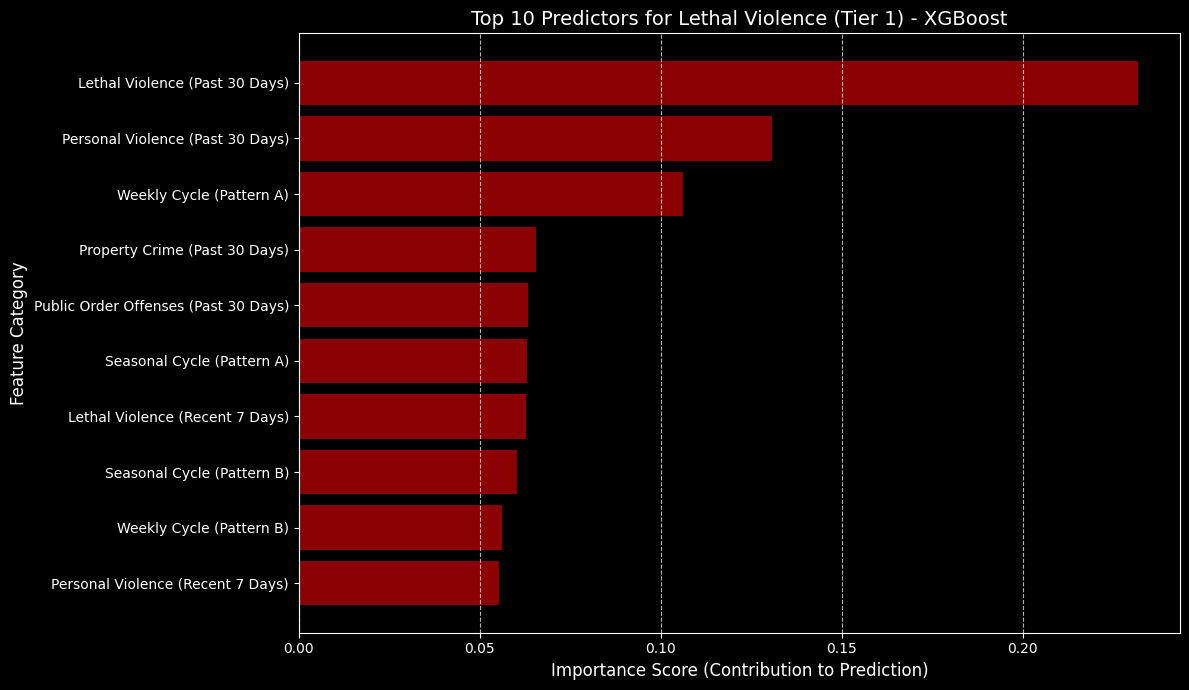

In [ ]:
# ==========================================
# 6. FEATURE IMPORTANCE (XGBOOST TIER 1)
# ==========================================


xgb_tier1_model = trained_estimators['XGBoost'][0]
importances = xgb_tier1_model.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=True).tail(10)

label_map = {
    'tier1_lag_30d': 'Lethal Violence (Past 30 Days)',
    'tier2_lag_30d': 'Personal Violence (Past 30 Days)',
    'dow_sin': 'Weekly Cycle (Pattern A)',
    'tier3_lag_30d': 'Property Crime (Past 30 Days)',
    'tier4_lag_30d': 'Public Order Offenses (Past 30 Days)',
    'month_cos': 'Seasonal Cycle (Pattern A)',
    'tier1_lag_7d': 'Lethal Violence (Recent 7 Days)',
    'month_sin': 'Seasonal Cycle (Pattern B)',
    'dow_cos': 'Weekly Cycle (Pattern B)',
    'tier2_lag_7d': 'Personal Violence (Recent 7 Days)'
}

feat_imp_df['Human_Feature'] = feat_imp_df['Feature'].map(label_map).fillna(feat_imp_df['Feature'])

plt.figure(figsize=(12, 7))
plt.barh(feat_imp_df['Human_Feature'], feat_imp_df['Importance'], color='darkred')
plt.title('Top 10 Predictors for Lethal Violence (Tier 1) - XGBoost', fontsize=14)
plt.xlabel('Importance Score (Contribution to Prediction)', fontsize=12)
plt.ylabel('Feature Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 7. SAVE PROJECT ARTIFACTS
# ==========================================


if not os.path.exists(save_path):
    os.makedirs(save_path)

joblib.dump(trained_estimators, os.path.join(save_path, 'crime_independent_models.joblib'))
joblib.dump(scaler, os.path.join(save_path, 'data_scaler.joblib'))
joblib.dump(features, os.path.join(save_path, 'feature_names.joblib'))
joblib.dump(cv_results_df, os.path.join(save_path, 'cv_results_df.joblib'))
joblib.dump(performance_df, os.path.join(save_path, 'performance_df.joblib'))
joblib.dump(spatial_temporal_df, os.path.join(save_path, 'spatial_temporal_df.joblib'))

print(f"\n✅ Success! All project artifacts saved to: {save_path}")


✅ Success! All project artifacts saved to: E:/NUS/IT5006/Crime Prediction Project/Saved_Models/
